In [26]:
# install necessary libraries
!pip install xgboost shap pandas matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set visual style
sns.set_theme(style="whitegrid")

# Load dataset with raw string path
path = r'data1.csv'
df = pd.read_csv(path)

# DATA COUNT & INFO
print(f"------------ Dataset Overview -------------\n")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"\nMissing Values Check:\n{df.isnull().sum().sum()} missing values found.")

------------ Dataset Overview -------------

Total Records: 7043
Total Features: 21

Missing Values Check:
0 missing values found.


In [15]:
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 20)       # Limit rows so it's not too long

In [48]:
# This highlights the Max value in 'MonthlyCharges' and adds a gradient to 'tenure'
(df.head(10).style
 .background_gradient(cmap='Blues', subset=['tenure'])
 .highlight_max(color='lightgreen', subset=['MonthlyCharges'])
 .set_caption("Sample of Churn Data with Feature Highlighting")
 .set_properties(**{'text-align': 'center', 'border': '1px solid black'}))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850000,29.850000,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950000,1889.500000,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850000,108.150000,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300000,1840.750000,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700000,151.650000,1
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.650000,820.500000,1
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.100000,1949.400000,0
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.750000,301.900000,0
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.800000,3046.050000,1
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.150000,3487.950000,0


Dropped 11 rows with missing TotalCharges.


C:\Users\Tanya Gopal\AppData\Local\Temp\ipykernel_25960\3634831510.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='viridis')


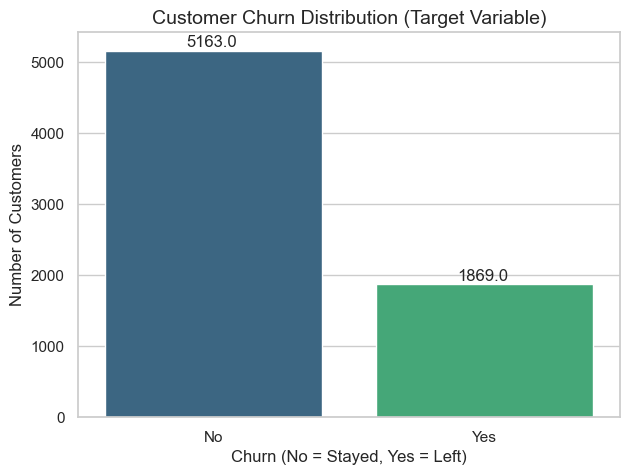

In [5]:
# Cleaning: Convert TotalCharges and drop missing rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
initial_count = len(df)
df.dropna(inplace=True)
print(f"Dropped {initial_count - len(df)} rows with missing TotalCharges.")

# Visualize Target Balance
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Customer Churn Distribution (Target Variable)', fontsize=14)
plt.xlabel('Churn (No = Stayed, Yes = Left)')
plt.ylabel('Number of Customers')
# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 50))
plt.show()

C:\Users\Tanya Gopal\AppData\Local\Temp\ipykernel_25960\2568168855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='magma')


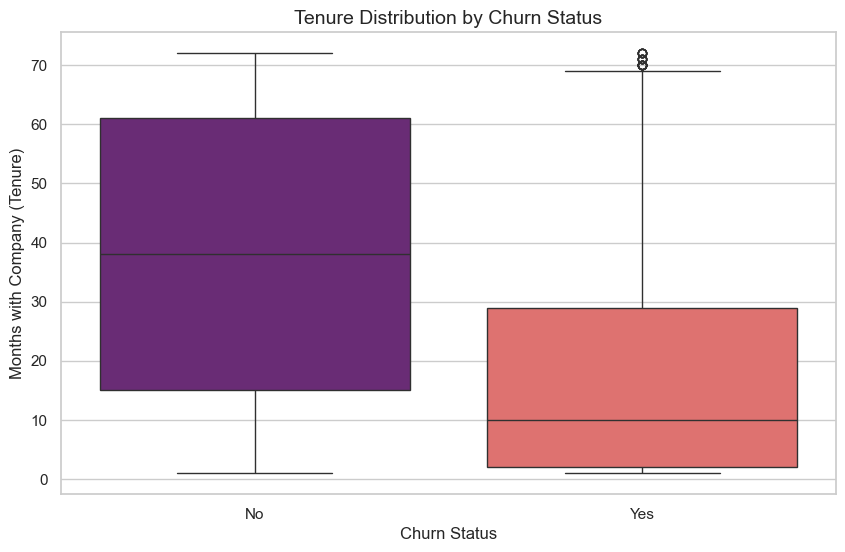

Training set size: 5625 samples
Testing set size: 1407 samples


In [7]:
# Visualize Tenure vs Churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='magma')
plt.title('Tenure Distribution by Churn Status', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Months with Company (Tenure)')
plt.show()

# Convert Target and One-Hot Encode
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
X = pd.get_dummies(df.drop(['customerID', 'Churn'], axis=1), drop_first=True)
y = df['Churn']

# Split data (80/20 ratio is global standard)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

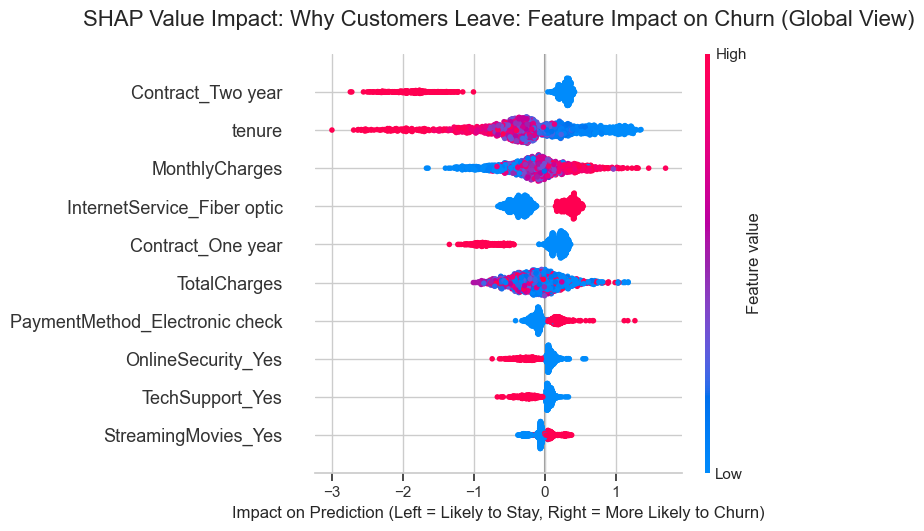

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.title("SHAP Value Impact: Why Customers Leave: Feature Impact on Churn (Global View)", fontsize=16, pad=20)

# Generate SHAP Summary Plot
# max_display=10 keeps it clean by only showing the top 10 influencers
shap.summary_plot(shap_values, X_test, max_display=10, show=False)

plt.xlabel("Impact on Prediction (Left = Likely to Stay, Right = More Likely to Churn)", fontsize=12)
plt.show()

In [28]:
print(f"✅ Data processed successfully.")
print(f"📊 Total Customers Analyzed: {len(df)}")
print(f"📉 Churn Rate in Dataset: {df['Churn'].mean()*100:.2f}%")
print("-" * 30)
print(f"🚀 Training model on {X_train.shape[0]} samples...")

✅ Data processed successfully.
📊 Total Customers Analyzed: 7032
📉 Churn Rate in Dataset: 26.58%
------------------------------
🚀 Training model on 5625 samples...


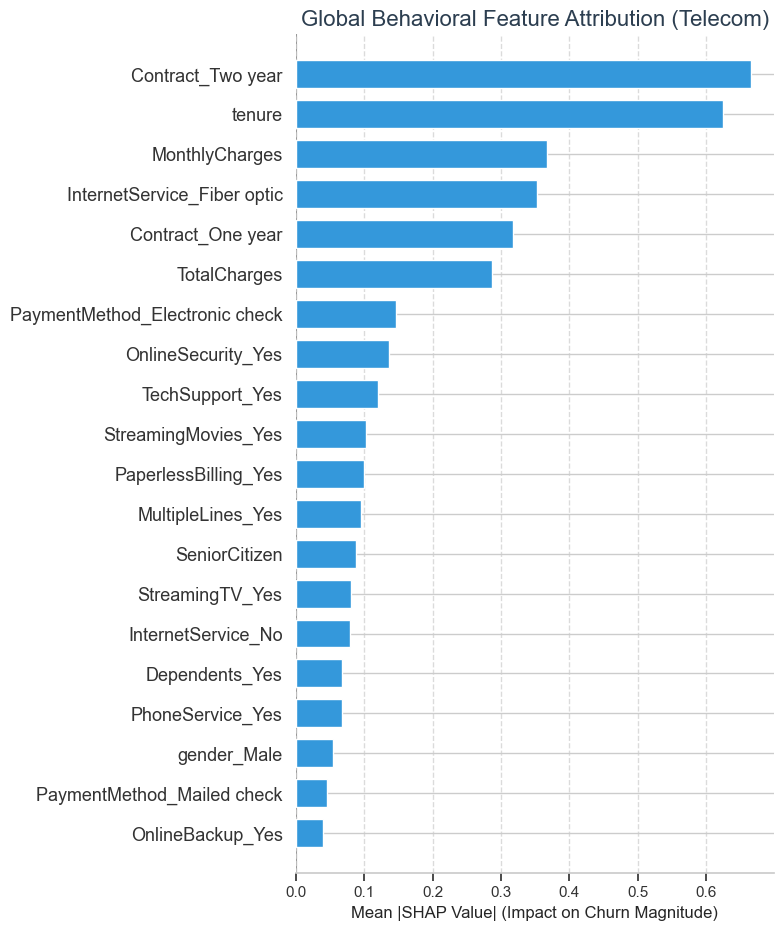

In [30]:
# Summary of Behavioral Drivers
plt.figure(figsize=(10, 8))
plt.title('Global Behavioral Feature Attribution (Telecom)', fontsize=16, color='#2c3e50')

# Plotting with custom labels
shap.summary_plot(shap_values, X_test, plot_type="bar", color='#3498db', show=False)

plt.xlabel("Mean |SHAP Value| (Impact on Churn Magnitude)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

--- Behavioral Data Summary ---
Total Customer Base: 7032
Baseline Churn Rate: 26.58%
Average Tenure of Loyalists: 37.7 months
Average Tenure of Churners: 18.0 months


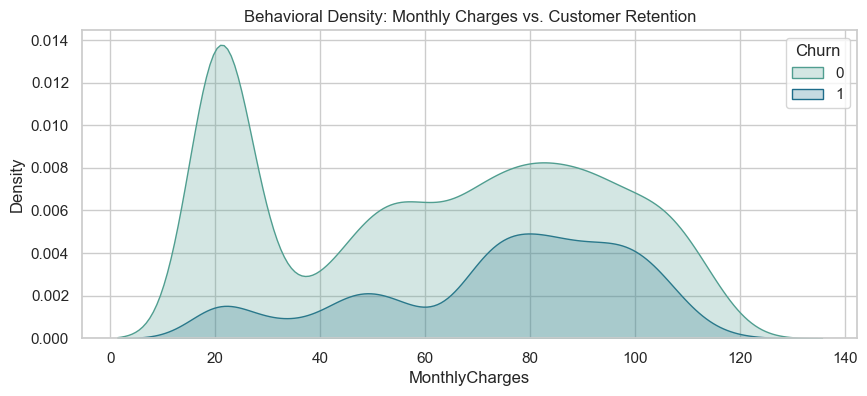

In [32]:
# Print Class Distribution & Key Behavioral Metrics
print(f"--- Behavioral Data Summary ---")
print(f"Total Customer Base: {len(df)}")
print(f"Baseline Churn Rate: {df['Churn'].mean()*100:.2f}%")
print(f"Average Tenure of Loyalists: {df[df['Churn']==0]['tenure'].mean():.1f} months")
print(f"Average Tenure of Churners: {df[df['Churn']==1]['tenure'].mean():.1f} months")

# Visualizing the 'Behavioral' spread of Monthly Charges
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette='crest')
plt.title('Behavioral Density: Monthly Charges vs. Customer Retention')
plt.show()

In [40]:
import warnings
import logging
import matplotlib

# 1. Import the logging module to silence the font manager
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. Suppress UserWarnings (this hides the font fallback messages)
warnings.filterwarnings("ignore", category=UserWarning)

# 3. Set global plot parameters for consistent professional styling
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Environment configured: Font warnings silenced and styles applied.")


✅ Environment configured: Font warnings silenced and styles applied.


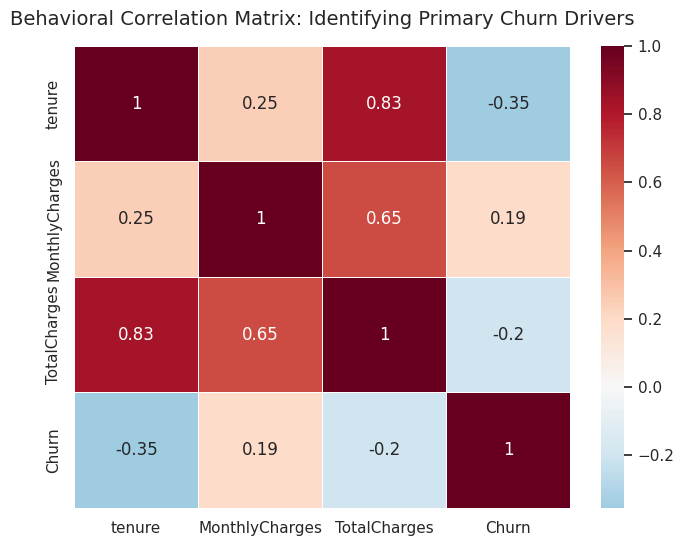

In [42]:
# Select a few key behavioral columns for the correlation analysis
behavioral_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
# Note: Ensure you use the 'df' before one-hot encoding for better labels
corr_matrix = df[behavioral_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, linewidths=0.5)
plt.title("Behavioral Correlation Matrix: Identifying Primary Churn Drivers", fontsize=14, pad=15)
plt.show()

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

# Create a Performance Table
metrics = {
    "Metric": ["Accuracy", "Precision (Churn)", "Recall (Churn)", "F1-Score"],
    "Score": [
        f"{accuracy_score(y_test, y_pred):.2%}",
        f"{precision_score(y_test, y_pred):.2%}",
        f"{recall_score(y_test, y_pred):.2%}",
        f"{f1_score(y_test, y_pred):.2%}"
    ]
}

performance_df = pd.DataFrame(metrics)
display(performance_df.style.set_caption("Final Model Performance Summary").hide(axis='index'))

Metric,Score
Accuracy,78.39%
Precision (Churn),61.82%
Recall (Churn),48.93%
F1-Score,54.63%


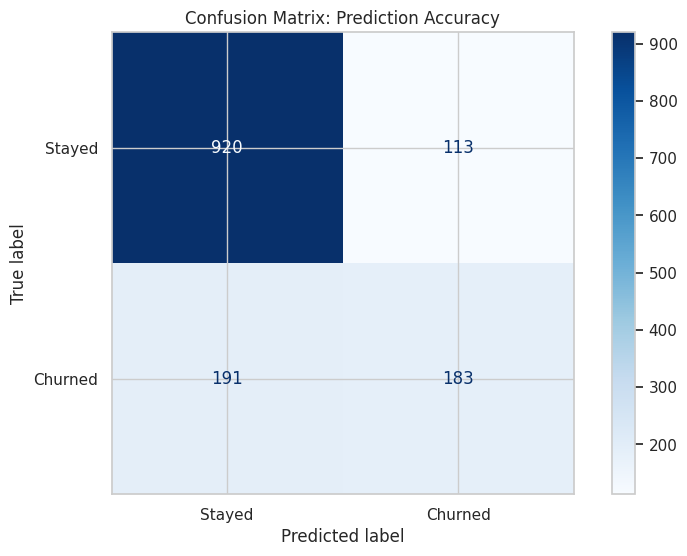

In [46]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Prediction Accuracy')
plt.show()